In [1]:
import sys                                                                                                                                                                                                        
sys.path.insert(0, '/nfs/home/svu/e1498138/localgit/FEWNEW/work')                                                                                                                                                   
                                                                                                                                                                                                                    
from GWfuncs_noise import GravWaveAnalysis, build_waveform_response                                                                                                                                                 
from loglike_phasemax_noise import LogLike                                                                                                                                                                           
import numpy as np                                                                                                                                                                                                  
import cupy as cp

In [2]:
import matplotlib.pyplot as plt
from scipy.stats import norm


In [3]:
use_gpu=True                                                                                                                                       
T = 3/12        # years                 
dt = 10.0       # seconds

# Source parameters
m1 = 1e6
m2 = 1e1
a = 0.7
p0 = 9
e0 = 0.4
xI0 = 1.0
dist = 5  # Gpc
qS = np.pi
phiS = 0.
qK =  0.
phiK = 0.
Phi_phi0 = 0.4
Phi_theta0 = 0.0
Phi_r0 = 0.5                                                                                                                           
                                                                                                                                                                                                                                                                                                                                                    
                                        
waveform_response = build_waveform_response(T=T, dt=dt, use_gpu=use_gpu,tdi_gen=1)                                                                                                    
         

In [4]:
params=[m1,m2,a,p0,e0,xI0,dist,qS,phiS,qK,phiK,Phi_phi0,Phi_theta0,Phi_r0]

In [5]:
gwf = GravWaveAnalysis(T=T, dt=dt, use_gpu=True,tdi_gen=1)

In [6]:
N_real = 1000
logl_noise_samples = np.zeros(N_real)
n_vals = np.arange(-1,6)  # n from -1 to 5
ell = 2  # quadrupole only

for i in range(N_real):
    loglike_i = LogLike(
        params=params,
        waveform_response=waveform_response,
        gwf=gwf,
        add_noise=True,
        verbose=False,
        ell=ell,
        n_vals=n_vals,
        M_mode=None,
        seed=i,
    )
    logl_noise_samples[i] = loglike_i(params)


In [ ]:
# Normal fit overlay
mu, sigma = norm.fit(logl_noise_samples)


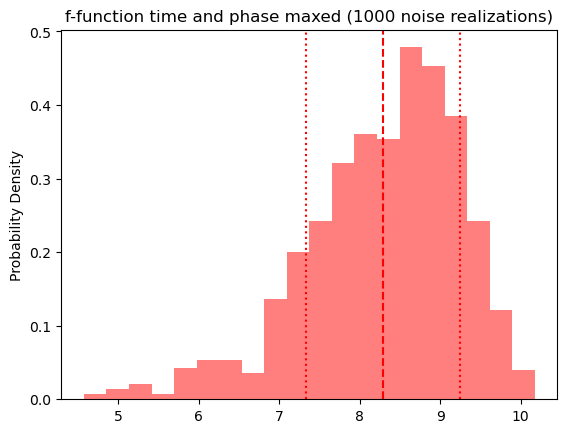

In [8]:
# Plot
fig, ax = plt.subplots()
ax.hist(logl_noise_samples, bins=20, density=True, alpha=0.5, color='red', label=r'$f(\theta^*)\ |\ H_1$ empirical')
ax.axvline(mu, color='r', linestyle='--', label='mean')
ax.axvline(mu - sigma, color='r', linestyle=':')
ax.axvline(mu + sigma, color='r', linestyle=':')
plt.title('f-function time and phase maxed (1000 noise realizations)')
plt.ylabel('Probability Density')
plt.show()